# Daily Walk-Forward Backtest

At **every trading day** we:
1. Run a full evolutionary optimisation using only data available up to that day.
2. Select a portfolio from the evolved Pareto frontier.
3. Hold that portfolio for exactly **one day** and record the out-of-sample return.

No future data ever leaks into the optimisation window.

In [14]:
import sys, warnings, time
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from utils.loss.template import ListLoss
from utils.loss.sharpe import Sharpe
from utils.loss.cvar import CVaR
from utils.loss.win_loss import WinLoss
from utils.populations.implementations import LongOnlyBC
from utils.domination import epsilon
from utils.backtest import Backtest

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

PALETTE = sns.color_palette('colorblind')
IMG_DIR = '../images'

np.random.seed(42)

## 1. Data

In [59]:
prices = pd.read_csv('../data/prices.csv', index_col='date')
prices = prices.iloc[0:1000]
returns = prices.pct_change().dropna()
dates = returns.index
returns_np = returns.values
n_assets = returns_np.shape[1]
asset_names = prices.columns.tolist()

print(f'Assets:   {asset_names}')
print(f'Returns:  {returns_np.shape[0]} days x {n_assets} assets')
print(f'Period:   {dates[0]}  to  {dates[-1]}')

Assets:   ['ASSET_0', 'ASSET_1', 'ASSET_2', 'ASSET_3', 'ASSET_4', 'ASSET_5', 'ASSET_6', 'ASSET_7', 'ASSET_8', 'ASSET_9', 'ASSET_10', 'ASSET_11', 'ASSET_12', 'ASSET_13', 'ASSET_14', 'ASSET_15', 'ASSET_16', 'ASSET_17', 'ASSET_18', 'ASSET_19', 'ASSET_20', 'ASSET_21', 'ASSET_22', 'ASSET_23', 'ASSET_24', 'ASSET_25', 'ASSET_26', 'ASSET_27', 'ASSET_28', 'ASSET_29', 'ASSET_30', 'ASSET_31', 'ASSET_32', 'ASSET_33', 'ASSET_34', 'ASSET_35', 'ASSET_36', 'ASSET_37', 'ASSET_38', 'ASSET_39', 'ASSET_40', 'ASSET_41', 'ASSET_42', 'ASSET_43', 'ASSET_44', 'ASSET_45', 'ASSET_46', 'ASSET_47', 'ASSET_48', 'ASSET_49']
Returns:  999 days x 50 assets
Period:   2021-01-05  to  2024-11-01


## 2. Backtest Configuration

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `train_window` | 252 | ~1 year of history before first trade |
| `step_size` | 1 | re-evolve and rebalance every day |
| `expanding` | True | use all available history (no data dropped) |
| `population_size` | 5,000 | kept small for daily speed |
| `n_generations` | 5 | enough to converge at this pop size |

In [61]:
TRAIN_WINDOW = 252
STEP_SIZE = 1
POP_SIZE = 10_000
N_GENERATIONS = 10

losses = [Sharpe('Sharpe Ratio'), CVaR('CVaR (1%)', alpha = 0.01), WinLoss('WinLoss')]
list_loss = ListLoss(losses)

bt = Backtest(
    population_cls=LongOnlyBC,
    population_kwargs={'problem_dimension': n_assets, 'population_size': POP_SIZE},
    list_loss=list_loss,
    domination_fn=epsilon.epsilon_dominant,
    domination_kwargs={'epsilon': 0.1},
    n_generations=N_GENERATIONS,
)

n_oos_days = len(returns_np) - TRAIN_WINDOW
print(f'OOS days to simulate: {n_oos_days}')
print(f'Evolutions to run:    {n_oos_days}')
print(f'OOS period:           {dates[TRAIN_WINDOW]}  to  {dates[-1]}')

OOS days to simulate: 747
Evolutions to run:    747
OOS period:           2021-12-23  to  2024-11-01


## 3. Run Daily Backtest

In [62]:
t0 = time.time()

bt_result = bt.run(
    returns=returns_np,
    train_window=TRAIN_WINDOW,
    step_size=STEP_SIZE,
    expanding=True,
    verbose=True,
)

elapsed = time.time() - t0
print(f'Elapsed:       {elapsed/60:.1f} min  ({elapsed/n_oos_days:.2f} s / day)')
print(f'OOS days:      {len(bt_result.portfolio_returns)}')
print(f'Total return:  {bt_result.total_return:+.2%}')

Step   0  |  train [0:252]  |  OOS [252:253]  |  cumulative: +0.0142
Step   1  |  train [0:253]  |  OOS [253:254]  |  cumulative: +0.0260
Step   2  |  train [0:254]  |  OOS [254:255]  |  cumulative: +0.0181
Step   3  |  train [0:255]  |  OOS [255:256]  |  cumulative: +0.0073
Step   4  |  train [0:256]  |  OOS [256:257]  |  cumulative: +0.0032
Step   5  |  train [0:257]  |  OOS [257:258]  |  cumulative: -0.0044
Step   6  |  train [0:258]  |  OOS [258:259]  |  cumulative: +0.0024
Step   7  |  train [0:259]  |  OOS [259:260]  |  cumulative: +0.0217
Step   8  |  train [0:260]  |  OOS [260:261]  |  cumulative: +0.0199
Step   9  |  train [0:261]  |  OOS [261:262]  |  cumulative: +0.0292
Step  10  |  train [0:262]  |  OOS [262:263]  |  cumulative: +0.0306
Step  11  |  train [0:263]  |  OOS [263:264]  |  cumulative: +0.0304
Step  12  |  train [0:264]  |  OOS [264:265]  |  cumulative: +0.0266
Step  13  |  train [0:265]  |  OOS [265:266]  |  cumulative: +0.0158
Step  14  |  train [0:266]  |  OOS

## 4. Equity Curve

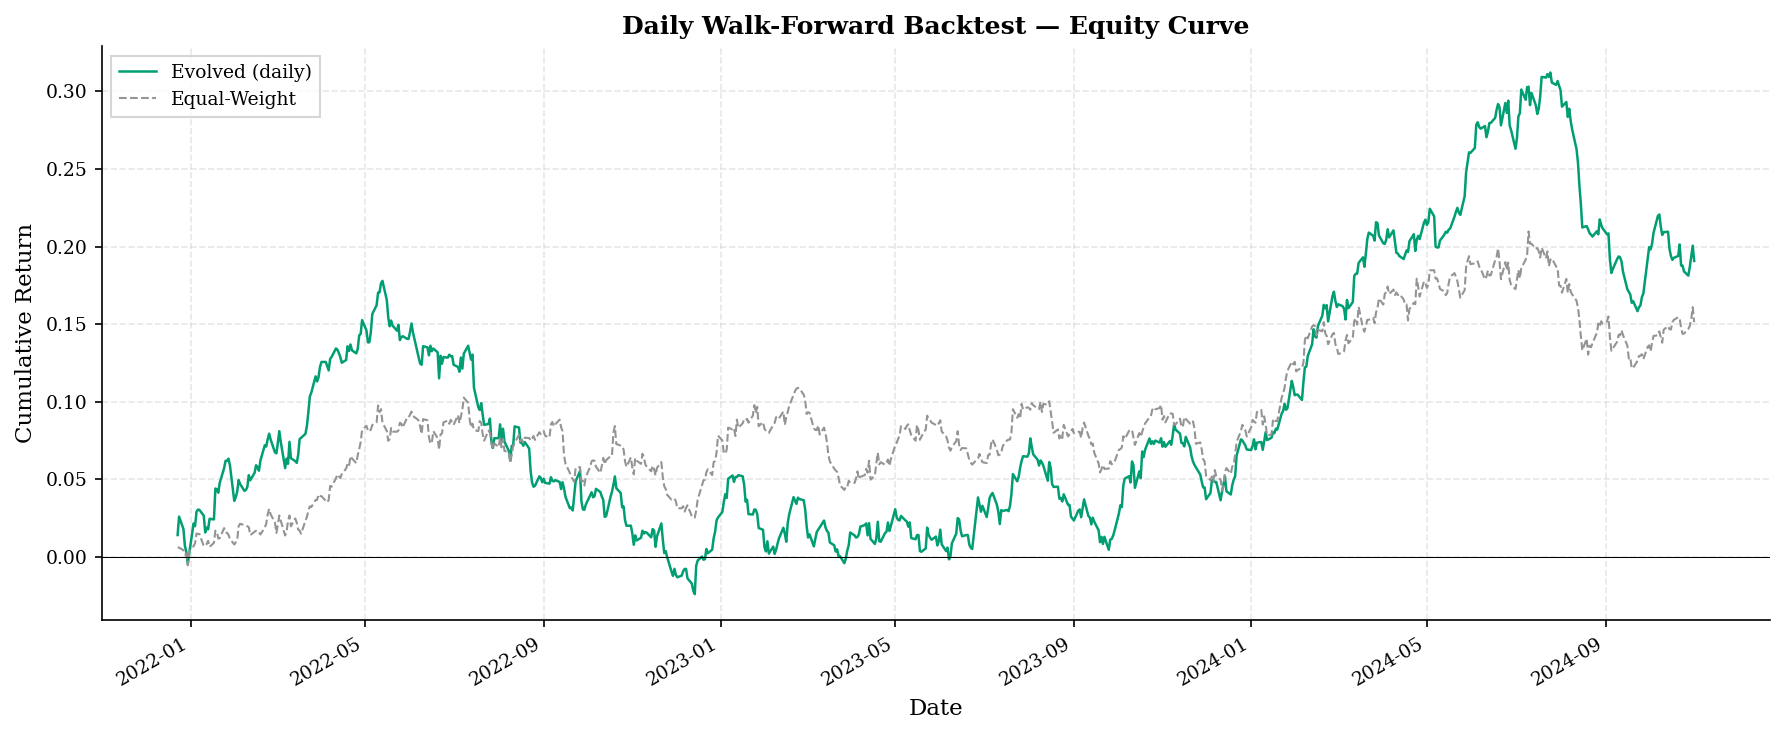

In [63]:
oos_dates = dates[TRAIN_WINDOW : TRAIN_WINDOW + len(bt_result.portfolio_returns)]
oos_dates_dt = pd.to_datetime(oos_dates)

# Evolved strategy
cum_ret = bt_result.cumulative_returns

# Equal-weight benchmark
ew_weights = np.ones(n_assets) / n_assets
ew_daily = returns_np[TRAIN_WINDOW : TRAIN_WINDOW + len(cum_ret)] @ ew_weights
ew_cum = np.cumprod(1 + ew_daily) - 1

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(oos_dates_dt, cum_ret, color=PALETTE[2], linewidth=1.2, label='Evolved (daily)')
ax.plot(oos_dates_dt, ew_cum, color=PALETTE[7], linewidth=1.0, linestyle='--', label='Equal-Weight')
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return')
ax.set_title('Daily Walk-Forward Backtest — Equity Curve', fontweight='bold')
ax.legend(frameon=True, fancybox=False, edgecolor='0.8')
fig.autofmt_xdate()

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/bt_daily_equity.png', bbox_inches='tight')
plt.show()

## 5. Rolling Performance

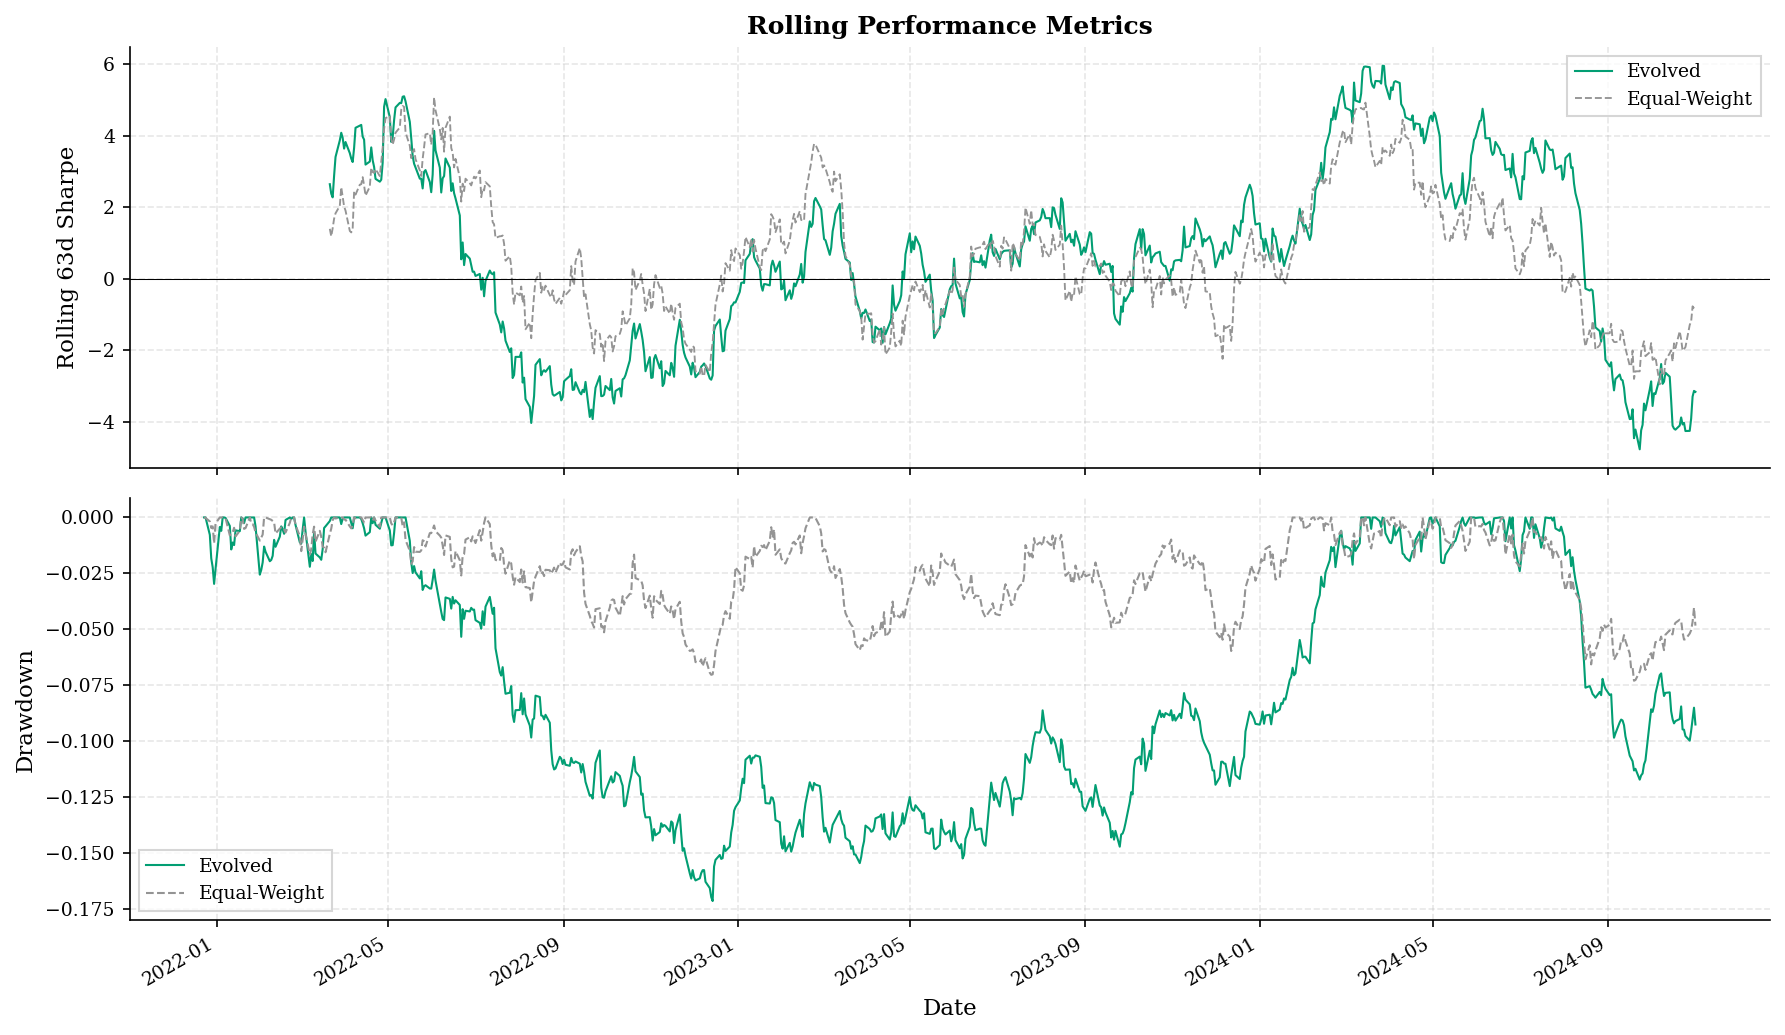

In [64]:
ROLL = 63  # ~quarterly

evo_series = pd.Series(bt_result.portfolio_returns, index=oos_dates_dt)
ew_series = pd.Series(ew_daily, index=oos_dates_dt)

roll_sharpe_evo = evo_series.rolling(ROLL).mean() / evo_series.rolling(ROLL).std() * np.sqrt(252)
roll_sharpe_ew = ew_series.rolling(ROLL).mean() / ew_series.rolling(ROLL).std() * np.sqrt(252)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Rolling Sharpe
ax = axes[0]
ax.plot(roll_sharpe_evo, color=PALETTE[2], linewidth=1.0, label='Evolved')
ax.plot(roll_sharpe_ew, color=PALETTE[7], linewidth=0.9, linestyle='--', label='Equal-Weight')
ax.axhline(0, color='k', linewidth=0.5)
ax.set_ylabel(f'Rolling {ROLL}d Sharpe')
ax.set_title('Rolling Performance Metrics', fontweight='bold')
ax.legend(frameon=True, fancybox=False, edgecolor='0.8')

# Rolling drawdown
ax = axes[1]
for series, label, c, ls in [
    (evo_series, 'Evolved', PALETTE[2], '-'),
    (ew_series, 'Equal-Weight', PALETTE[7], '--'),
]:
    wealth = (1 + series).cumprod()
    drawdown = wealth / wealth.cummax() - 1
    ax.plot(drawdown, color=c, linewidth=1.0, linestyle=ls, label=label)

ax.set_ylabel('Drawdown')
ax.set_xlabel('Date')
ax.legend(frameon=True, fancybox=False, edgecolor='0.8')

fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/bt_daily_rolling.png', bbox_inches='tight')
plt.show()

## 6. Portfolio Weight Evolution

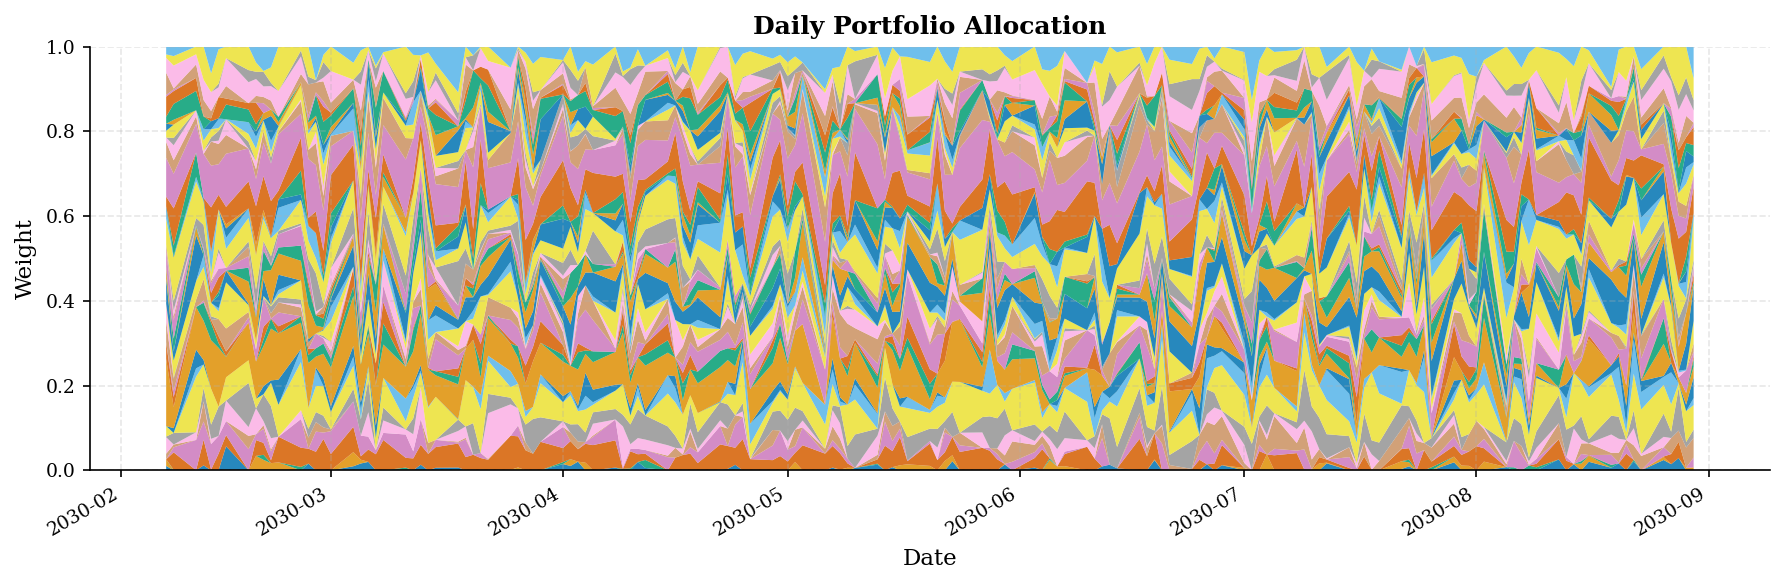

In [56]:
weight_history = np.array(bt_result.chosen_weights)

fig, ax = plt.subplots(figsize=(12, 4))
ax.stackplot(
    oos_dates_dt,
    weight_history.T,
    labels=asset_names,
    colors=PALETTE[:n_assets],
    alpha=0.85,
)
ax.set_xlabel('Date')
ax.set_ylabel('Weight')
ax.set_title('Daily Portfolio Allocation', fontweight='bold')
ax.set_ylim(0, 1)
#ax.legend(frameon=True, fancybox=False, edgecolor='0.8',
#          bbox_to_anchor=(1.02, 1), loc='upper left')
fig.autofmt_xdate()

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/bt_daily_weights.png', bbox_inches='tight')
plt.show()

## 7. Summary Statistics

In [58]:
def summary_stats(daily_returns, label):
    total = (1 + daily_returns).prod() - 1
    n_years = len(daily_returns) / 252
    ann_ret = (1 + total) ** (1 / n_years) - 1
    ann_vol = daily_returns.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    wealth = np.cumprod(1 + daily_returns)
    max_dd = (wealth / np.maximum.accumulate(wealth) - 1).min()
    return {
        'Strategy': label,
        'Total Return': f'{total:+.2%}',
        'Ann. Return': f'{ann_ret:+.2%}',
        'Ann. Volatility': f'{ann_vol:.2%}',
        'Sharpe Ratio': f'{sharpe:.2f}',
        'Max Drawdown': f'{max_dd:.2%}',
    }

stats = pd.DataFrame([
    summary_stats(bt_result.portfolio_returns, 'Evolved (daily)'),
    summary_stats(ew_daily, 'Equal-Weight'),
]).set_index('Strategy')

stats

,Total Return,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown
Strategy,,,,,
Evolved (daily),-1.46%,-2.49%,8.87%,-0.28,-11.31%
Equal-Weight,-3.16%,-5.35%,6.41%,-0.83,-9.27%
